# Waste Management Dataset - RNN
Goal: Predict the wastage volume that would be produce in future i.e, the next day using RNN

In [2]:
# Dataset path
path = '/content/drive/MyDrive/Tek works/Deep-Learning/Datasets/optimized_waste_management_data.csv'

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

## Load and Inspect Data

In [4]:
# Load
df = pd.read_csv(path)
df.head()

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [5]:
# Columns
df.columns

Index(['date', 'waste_volume', 'organic_waste', 'recyclable_waste',
       'hazardous_waste', 'collection_frequency', 'landfill_capacity_used',
       'recycling_rate'],
      dtype='object')

In [6]:
# Shape
df.shape

(1461, 8)

In [7]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    1461 non-null   object 
 1   waste_volume            1461 non-null   float64
 2   organic_waste           1461 non-null   float64
 3   recyclable_waste        1461 non-null   float64
 4   hazardous_waste         1461 non-null   float64
 5   collection_frequency    1461 non-null   object 
 6   landfill_capacity_used  1461 non-null   float64
 7   recycling_rate          1461 non-null   float64
dtypes: float64(6), object(2)
memory usage: 91.4+ KB


In [8]:
# Missing values
df.isnull().sum()

,0
date,0
waste_volume,0
organic_waste,0
recyclable_waste,0
hazardous_waste,0
collection_frequency,0
landfill_capacity_used,0
recycling_rate,0


- No missing values

In [9]:
# Extract required columns
df = df[['date', 'waste_volume']]
df.head()

,date,waste_volume
0,01-01-2020,48.85
1,02-01-2020,49.45
2,03-01-2020,51.03
3,04-01-2020,54.70
4,05-01-2020,51.74


## Data Transformation

In [10]:
# Convert Date column dtype to Date
print(df['date'].dtype)
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
print(df['date'].dtype)

object
datetime64[ns]


## Sort data
- Sort data by `date` column to ensure time-series data is chronological order

In [11]:
# Sort data
df = df.sort_values(by='date')
df.head()

,date,waste_volume
0,2020-01-01,48.85
1,2020-01-02,49.45
2,2020-01-03,51.03
3,2020-01-04,54.70
4,2020-01-05,51.74


## EDA

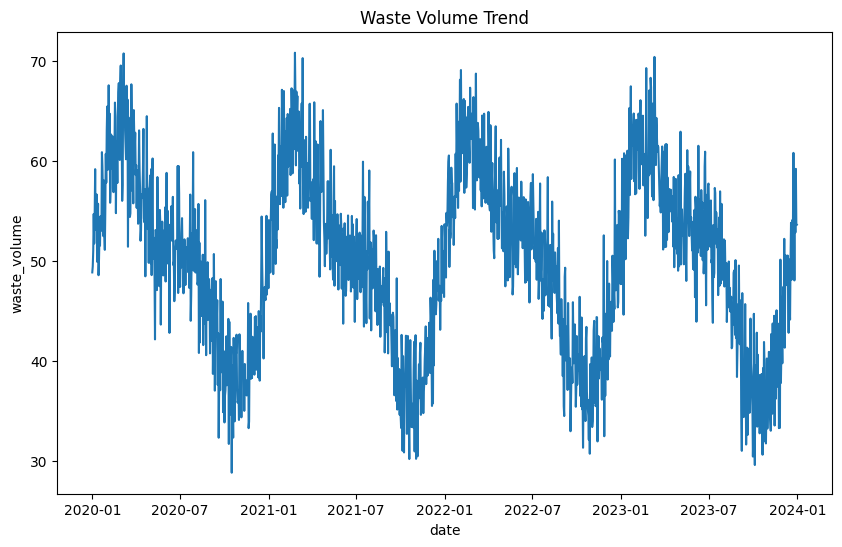

In [12]:
# Waste volume trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='date', y='waste_volume')
plt.title('Waste Volume Trend')
plt.show()

- **Observation**: Waste volume has seasonal trends in it.

## Normalize the data
- Neural networks perform better when the data values are scaled between 0 and 1

In [13]:
# Scale data values using MinMaxScaler
scaler = MinMaxScaler()
df['waste_volume'] = scaler.fit_transform(df[['waste_volume']])

## Create time series dataset
- Prepare the data for RNN by creating input sequences (X) and corresponding output values (y)

- Define:
  - Lookback period: `look_back`
  - Initialize empty input lists: `X_data`, and `y_data`
  - Populate `X_data` and `y_data` using `look_back`
  - Reshape `X_data` to 3D format (smaples, timestamps, features) suitable for the RNN input layer

**Significance of this step**: _This step converts raw time-series data into supervised input-output pairs, enabling the model to learn patterns and predict future values based on past observations._


In [14]:
# Define look back period
look_back = 10  # 10 days

# Initialize empty lists
X_data = []
y_data = []

# Populate X_data and y_data
for i in range(look_back, len(df)):
    X_data.append(df['waste_volume'].iloc[i-look_back:i])
    y_data.append(df['waste_volume'].iloc[i])

# Convert to numpy arrays
X_data = np.array(X_data)
y_data = np.array(y_data)

# Reshape X_data
# X_data shape: (samples, look_back, 1)
X_data = np.reshape(X_data, (X_data.shape[0], look_back, 1))

## Split dataset
- Split the dataset into training and testing sets

```
[ Past Data ----------- | Future Data ]
      Training               Testing
```

In [15]:
# Split into training and testing sets
# Shuffle = False for time series data
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    shuffle=False
)

## Build Model

```
Input → SimpleRNN(50) → Dense(1) → Output
```

- Model: RNN
- Class: Sequential from Tensorflow/Keras
- Layers: SimpleRNN from Tensorflow/Keras
- Activation Function: Tanh

**Significance of `return_sequence`**:
| Setting | Output                     |
| ------- | -------------------------- |
| False   | Only last output (h3)      |
| True    | Full sequence (h1, h2, h3) |
- When is return_sequences=True Correct?
  - Use it when:
  Stacking multiple RNN layers,
Sequence-to-sequence problems (e.g., translation)


In [16]:
# Initialize sequential model
model = Sequential()

# Add SimpleRNN layers
model.add(SimpleRNN(
    units=50,
    return_sequences=True,  # Output a sequence at every time step
    input_shape=(look_back, 1),
    activation='tanh' # Default for RNN
))

model.add(SimpleRNN(
    units=50,
    return_sequences=False,
    activation='tanh'
))

# Add Dense Layer
model.add(Dense(
    units=1, # 1 = single waste volume value
    activation='linear'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compile and Train Model

In [17]:
# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the model
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0786 - mae: 0.2345 - val_loss: 0.5232 - val_mae: 0.6785
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1264 - mae: 0.3014 - val_loss: 0.0660 - val_mae: 0.2180
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0256 - mae: 0.1209 - val_loss: 0.0163 - val_mae: 0.1014
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0140 - mae: 0.0955 - val_loss: 0.0331 - val_mae: 0.1483
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0160 - mae: 0.1023 - val_loss: 0.0320 - val_mae: 0.1454
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0165 - mae: 0.1039 - val_loss: 0.0368 - val_mae: 0.1589
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172 - mae: 0.1059 - val_loss: 0.0362 - val_mae: 0.1573
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 - mae: 0.1035 - val_loss: 0.0338 - val_mae: 0.1507
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154 - mae:

## Make Predictions and Inverse Scale

In [19]:
# Predict for X_test
y_pred = model.predict(X_test)
print(y_pred.shape)

# Inverse scale predictions
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
print(y_pred_inv.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
(291, 1)
(291, 1)


In [20]:
print(y_test.shape)
# Inverse scale actuals
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
print(y_test_inv.shape)

(291,)
(291, 1)


## Evaluate Model Performance

In [21]:
# Mean Squared Error
mse = mean_squared_error(y_test_inv, y_pred_inv)
print(f'Mean Squared Error: {mse}')

# Root Mean Squared Error
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

# Mean Absolute Error
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 16.896803208486357
Root Mean Squared Error: 4.110572126661489
Mean Absolute Error: 3.2944923463801747


## Visualization
- Visualize Predictions vs Actuals

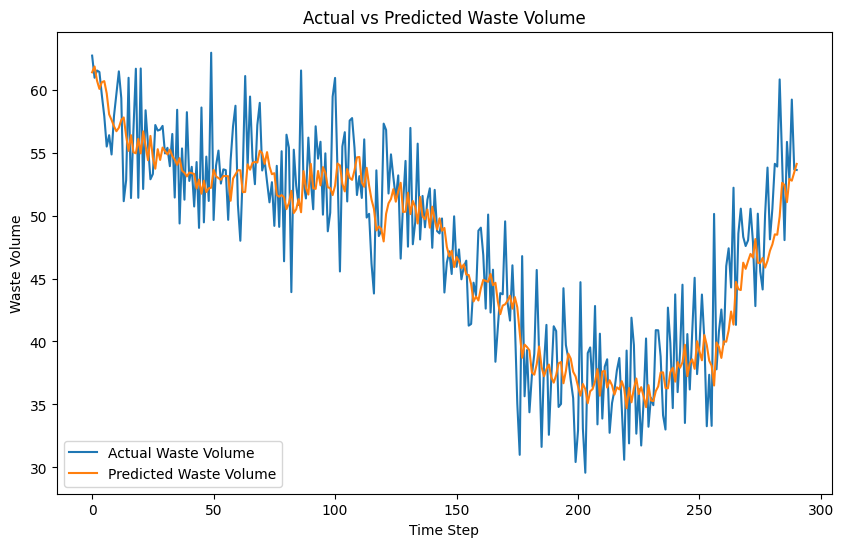

In [41]:
# Create figure
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(y_test_inv, label='Actual Waste Volume')

# Plot predicted values
plt.plot(y_pred_inv, label='Predicted Waste Volume')
plt.xlabel('Time Step')
plt.ylabel('Waste Volume')
plt.title('Actual vs Predicted Waste Volume')
plt.legend()
plt.show()

# Task
To achieve the goal of predicting the next day's waste volume, I'll perform the following steps:
1. **Prepare Input for Prediction**: Extract the last `look_back` (10) scaled `waste_volume` values from the `df` DataFrame.
2. **Reshape Input**: Reshape the extracted values into a 3D array (`(1, look_back, 1)`) as required by the RNN model.
3. **Predict Next Day's Waste Volume**: Use the trained `model` to predict the next day's waste volume from the prepared input.
4. **Inverse Scale the Prediction**: Convert the predicted scaled value back to its original unit using the `scaler`.
5. **Display Predicted Waste Volume**: Print the predicted waste volume for the next day.

## Prepare Input for Prediction

### Subtask:
Extract the last 'look_back' number of scaled waste volume values from the DataFrame and reshape it into the 3D format required by the RNN model for prediction.


**Reasoning**:
Extract the last 'look_back' number of scaled waste volume values from the DataFrame and reshape it for the RNN model's prediction input.



In [43]:
last_10_days_scaled = df['waste_volume'].iloc[-look_back:].values
X_next_day = last_10_days_scaled.reshape(1, look_back, 1)

print(f"Shape of X_next_day: {X_next_day.shape}")

Shape of X_next_day: (1, 10, 1)


**Reasoning**:
Predict the next day's waste volume using the trained RNN model and the prepared input `X_next_day`.



In [44]:
next_day_scaled_prediction = model.predict(X_next_day)
print(f"Scaled prediction for next day: {next_day_scaled_prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
Scaled prediction for next day: 0.5704


**Reasoning**:
The scaled prediction needs to be converted back to its original units using the `scaler` object to get the actual waste volume value for the next day.



In [45]:
next_day_prediction = scaler.inverse_transform(next_day_scaled_prediction)
print(f"Predicted waste volume for the next day: {next_day_prediction[0][0]:.2f}")

Predicted waste volume for the next day: 52.78


## Final Task

### Subtask:
Summarize the predicted waste volume for the next day.


## Summary:

### Q&A
*   **What is the predicted waste volume for the next day?**
    The predicted waste volume for the next day is 52.78 units.

### Data Analysis Key Findings
*   The input data for the prediction, `X_next_day`, was successfully prepared by extracting the last 10 scaled waste volume values and reshaping them into a 3D array with the shape `(1, 10, 1)`, as required by the RNN model.
*   The RNN model predicted a scaled waste volume of 0.5704 for the subsequent day.
*   After inverse transforming the scaled prediction, the final predicted waste volume for the next day was calculated to be 52.78 units.

### Insights or Next Steps
*   The predicted waste volume of 52.78 units can be used for operational planning, such as resource allocation for waste collection and processing for the upcoming day.
*   To enhance the reliability of these predictions, it would be beneficial to track actual waste volumes against predicted values to continuously evaluate and potentially refine the model's performance.
